# Unit 4 — Notebook 1: Containerizing Your Portfolio Model with Docker

**What you will learn:**
1. What Docker is and why it solves the "works on my machine" problem
2. How a Dockerfile, image, container, and registry relate to each other
3. How to stage **your own model artifact** into a build context and write a Dockerfile around it
4. How to build and run Docker containers and inspect them with CLI commands

**The model:** this notebook containerizes the portfolio model you exported from AIAT 114 or AIAT 122 — the same artifact Units 1 and 2 served over HTTP. See [`../../PORTFOLIO_MODEL.md`](../../PORTFOLIO_MODEL.md). If you have not exported one yet, the notebook builds and containerizes the named fallback `wdbc-baseline` and says so in its output.

**How to use this notebook:** Run cells top to bottom. `%%writefile` cells create real files on disk. `subprocess` cells show you the commands — they run for real when Docker is installed *and its daemon is running*; in every other case (no CLI, stopped daemon) they print the command plus the typical output, clearly labeled, so you can follow along on any machine.

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 01 "00. Python Libraries for AI" — you installed a specific stack of libraries to make AI code run at all; a Dockerfile writes that install list down so any machine can rebuild the same environment, which is what ends "works on my machine".

**Used later in:** Course 12 (AIAT 126) — Unit 5, lesson 01 "Project Documentation and Presentation", whose deliverable checklist asks for live-demo setup instructions — a container image is the least fragile way to supply them.


## 📰 The week `pip install` shipped malware to PyTorch users

Between **25 and 30 December 2022**, anyone who installed PyTorch-nightly on Linux via `pip` got a package called `torchtriton` — not the one PyTorch publishes on its own index, but a **malicious package of the same name uploaded to PyPI**. Because `pip` gives the public PyPI index precedence over an extra index, the attacker's version won. PyTorch's own advisory describes what the binary did on import: read `/etc/hosts`, `/etc/passwd`, `$HOME/.gitconfig`, everything in `$HOME/.ssh/`, and the first 1,000 files in the home directory, then exfiltrate the contents over encrypted DNS queries to an attacker-controlled domain. PyTorch's fix was to rename the dependency and register a placeholder on PyPI so the name could not be claimed again.

Read the Dockerfile you are about to write with that in mind. `RUN pip install --no-cache-dir -r requirements.txt` is the line where an outside world with its own opinions enters your image. What that line resolves to depends on **when** you build, **which indexes** are configured, and **how tightly** `requirements.txt` is pinned. Two builds of the same Dockerfile a week apart are not necessarily the same image.

**What goes wrong without this lesson.** "Works on my machine" is not a joke about carelessness; it is a statement about a dozen invisible dependencies — Python patch version, OpenBLAS build, glibc, a system library some wheel links against. A container image writes all of them down and ships them together, which is what turns "here is my model" into something a colleague, a CI runner and a Kubernetes node can all run identically.

---
## Section 1 — The "Works on My Machine" Problem

You train a model on your laptop (Python 3.10, scikit-learn 1.3, numpy 1.24). You hand it to a colleague running Python 3.8 on Ubuntu, or you deploy it to a server with a different OS. It breaks.

**Docker solves this** by packaging your code, model, and every dependency together into a single artifact — an *image* — that runs identically anywhere Docker is installed.

The diagram below shows the transformation:


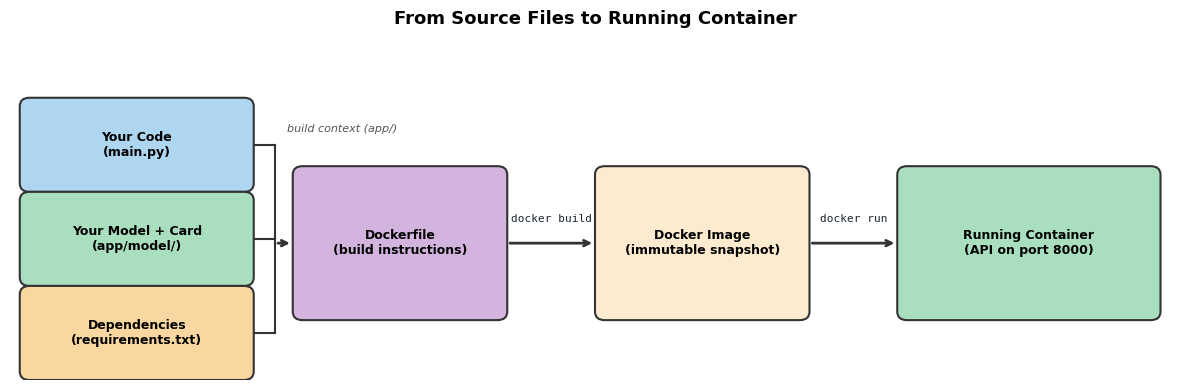

In [1]:
# WHAT: draw the Docker pipeline diagram: source files -> Dockerfile -> image -> container.
# WHY: these four boxes are the whole lesson — every cell below builds one of
# them; keep this picture in mind as the map.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

PAD = 0.1          # FancyBboxPatch draws this far outside the (x, y, w, h) box
MID = 1.6          # vertical centre line of the pipeline


# Box helper
def box(ax, x, y, w, h, label, color):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=9, fontweight='bold', wrap=True)


def step_arrow(x0, x1, label):
    """Arrow from x0 to x1 on the centre line, with the command ABOVE it."""
    ax.annotate('', xy=(x1, MID), xytext=(x0, MID),
                arrowprops=dict(arrowstyle='->', lw=2, color='#333'))
    ax.text((x0 + x1) / 2, MID + 0.22, label, ha='center', va='bottom',
            fontsize=8, family='monospace', color='#1B2631')


# The three things we ship: code, YOUR staged model artifact, and pinned dependencies.
# Left: inputs
box(ax, 0.2, 2.3, 2.2, 0.9, 'Your Code\n(main.py)', '#AED6F1')
box(ax, 0.2, 1.2, 2.2, 0.9, 'Your Model + Card\n(app/model/)', '#A9DFBF')
box(ax, 0.2, 0.1, 2.2, 0.9, 'Dependencies\n(requirements.txt)', '#FAD7A0')

# All three inputs feed the SAME build context, so gather them onto one spine
# before the arrow into the Dockerfile — one arrow out of the middle box alone
# would suggest only the model is copied.
SPINE = 2.72
for y_centre in (2.75, 1.65, 0.55):
    ax.plot([2.4 + PAD, SPINE], [y_centre, y_centre], lw=1.5, color='#333')
ax.plot([SPINE, SPINE], [0.55, 2.75], lw=1.5, color='#333')
# Anchored to the RIGHT of the spine: centred on it, this label printed on top
# of the 'Your Code' box's corner.
ax.text(SPINE + 0.12, 2.88, 'build context (app/)', ha='left', va='bottom',
        fontsize=8, style='italic', color='#555')
step_arrow(SPINE, 3.0 - PAD, '')

# Dockerfile box
box(ax, 3.0, 0.8, 2.0, 1.6, 'Dockerfile\n(build instructions)', '#D2B4DE')

step_arrow(5.0 + PAD, 6.1 - PAD, 'docker build')

# Image box
box(ax, 6.1, 0.8, 2.0, 1.6, 'Docker Image\n(immutable snapshot)', '#FDEBD0')

step_arrow(8.1 + PAD, 9.2 - PAD, 'docker run')

# Container box
box(ax, 9.2, 0.8, 2.5, 1.6, 'Running Container\n(API on port 8000)', '#A9DFBF')

ax.set_title('From Source Files to Running Container', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


**Read the map.** Follow it left to right, because that is the order the rest of this
notebook runs in. On the left, three separate things — your code, your staged model
artifact, your pinned dependencies — are gathered onto one spine labelled *build context*:
Docker copies that one folder and nothing outside it, which is why Section 3 has to
*stage* your model into `app/` before anything else can happen. The two labelled arrows
are the only two commands in the whole lesson. `docker build` turns the recipe into an
immutable image; `docker run` turns that image into a live process serving on port 8000.
Everything between here and the summary is one of these four boxes being filled in.

---
## Section 2 — Docker Concepts: Image, Container, Registry

| Concept | Analogy | Description |
|---|---|---|
| **Dockerfile** | Recipe | Text file with instructions for building an image |
| **Image** | Cake (baked) | Read-only snapshot produced by `docker build` |
| **Container** | Serving a slice | A running instance of an image |
| **Registry** | Cookbook library | Remote store for images (Docker Hub, ECR, GCR) |

One image can spawn many containers simultaneously — this is how you scale horizontally.


---
## Section 3 — Stage the Model and Write the App Files

Docker builds from a **build context**: one folder, and nothing outside it. Your portfolio model lives in `~/ai-diploma-portfolio/`, which is outside `app/` — so the first real containerization step is *staging*: copying the artifact and its card into the context.

That copy is not a notebook convenience. In a production pipeline the same step pulls the artifact from a model registry (`mlflow artifacts download`, `aws s3 cp`, a GitHub release asset). The image must contain everything it needs, because at runtime there is no home directory, no notebook, and no network guarantee.

We then write the serving app and the pinned requirements with `%%writefile`, so they land on disk exactly as they would in a real project.

In [2]:
# WHAT: create the build context folder that Docker will copy into the image.
# WHY: everything the container needs - code, model, requirements, Dockerfile -
# has to live under this one directory. Nothing outside it can be COPYed.
import os
os.makedirs('app/model', exist_ok=True)
print('Created app/ and app/model/')


Created app/ and app/model/


In [3]:
%%writefile app/stage_model.py
# WHAT: copy YOUR portfolio artifact and its card into app/model/.
# WHY: Docker can only copy files that live inside the build context (the app/
# folder). Your model lives in your home directory, so "staging" it into the
# context is a real build step - in a production pipeline this same step is an
# `aws s3 cp` or `mlflow artifacts download` from a model registry.
"""Stage the AIAT 125 portfolio model into the Docker build context."""
import json
import os
import shutil
from pathlib import Path

PORTFOLIO = Path(os.environ.get("AI_DIPLOMA_PORTFOLIO",
                                str(Path.home() / "ai-diploma-portfolio")))
DEST = Path(__file__).parent / "model"


def stage(portfolio: Path = PORTFOLIO, dest: Path = DEST) -> dict:
    """Copy model_card.json + the artifact it names into dest/. Returns the card."""
    card_path = portfolio / "model_card.json"
    if not card_path.exists():
        raise FileNotFoundError(
            f"No model_card.json in {portfolio}. Export a model first - see "
            "Course 11/PORTFOLIO_MODEL.md - or run any Unit 1 notebook to build "
            "the named fallback."
        )
    card = json.loads(card_path.read_text())
    dest.mkdir(parents=True, exist_ok=True)
    shutil.copy2(card_path, dest / "model_card.json")
    shutil.copy2(portfolio / card["artifact"], dest / card["artifact"])
    return card


if __name__ == "__main__":
    staged = stage()
    print(f"Staged '{staged['name']}' ({staged['artifact']}) into {DEST}")


Overwriting app/stage_model.py


In [4]:
# WHAT: load the portfolio model (building the named fallback if needed), then
# run the staging script exactly as its docstring says: python stage_model.py.
# WHY: the image is only as good as what we put in the build context. Running the
# real script here means the notebook and the container ship the SAME bytes.
import json
import subprocess
import sys
from pathlib import Path

for _d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_d / "portfolio_model.py").exists():
        COURSE11 = _d
        break
else:
    raise FileNotFoundError("Could not find portfolio_model.py - run this notebook from inside Course 11.")

if str(COURSE11) not in sys.path:
    sys.path.insert(0, str(COURSE11))

import portfolio_model as pf

model, card = pf.load_portfolio_model()

# Run the staging script as a script - the same command you would put in a Makefile.
result = subprocess.run([sys.executable, "stage_model.py"], cwd="app",
                        capture_output=True, text=True, timeout=120)
print()
print(result.stdout.strip() or result.stderr.strip())
result.check_returncode()

print("\nBuild context now contains:")
for f in sorted(Path("app/model").iterdir()):
    print(f"  app/model/{f.name}  ({f.stat().st_size / 1024:.1f} KB)")


FALLBACK MODEL 'wdbc-baseline' — this is NOT your model.
  directory   : /Users/abdullah/ai-diploma-portfolio
  artifact    : model.joblib  (sklearn)
  task        : classification  ->  2 classes ['malignant', 'benign']
  features    : 30 (first three: ['mean radius', 'mean texture', 'mean perimeter'])
  accuracy    : 0.9825 on held-out 20% (random_state=42, stratified)
  Export your own model from AIAT 114 or AIAT 122 and re-run: see Course 11/PORTFOLIO_MODEL.md

Staged 'wdbc-baseline' (model.joblib) into /Users/abdullah/Downloads/AI Diploma/Course 11/unit4-containers-orchestration/examples/app/model

Build context now contains:
  app/model/iris_rf.joblib  (182.5 KB)
  app/model/model.joblib  (2.2 KB)
  app/model/model_card.json  (10.2 KB)


In [5]:
%%writefile app/main.py
# WHAT: the inference server that runs INSIDE the container.
# WHY: note where the artifact comes from. Unit 1 and Unit 2 read the portfolio
# directory in your home folder; a container has no home folder to read. The
# model is baked in at "model/", relative to WORKDIR /app - the image IS the
# artifact store, which is exactly what makes it reproducible.
"""FastAPI inference server for the staged portfolio model."""
import json
import os
import re
from pathlib import Path

import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel, Field, create_model

MODEL_DIR = Path(os.environ.get("MODEL_DIR", "model"))
CARD = json.loads((MODEL_DIR / "model_card.json").read_text())
ARTIFACT = MODEL_DIR / CARD["artifact"]

if CARD["framework"] == "sklearn":
    import joblib
    _model = joblib.load(ARTIFACT)

    def probabilities(rows):
        return np.asarray(_model.predict_proba(rows))

elif CARD["framework"] == "onnx":
    import onnxruntime as ort
    _session = ort.InferenceSession(str(ARTIFACT), providers=["CPUExecutionProvider"])
    _input = _session.get_inputs()[0].name

    def probabilities(rows):
        logits = np.asarray(_session.run(None, {_input: np.asarray(rows, dtype=np.float32)})[0])
        exp = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)

else:
    raise RuntimeError(f"This image serves 'sklearn' or 'onnx' artifacts, not {CARD['framework']!r}.")


def api_field(name):
    slug = re.sub(r"\W+", "_", str(name).strip().lower()).strip("_")
    return f"f_{slug}" if not slug or slug[0].isdigit() else slug

FIELD_ORDER = [api_field(n) for n in CARD["feature_names"]]

PredictRequest = create_model(
    "PredictRequest",
    **{field: (float, Field(..., description=f"training column: {original}"))
       for field, original in zip(FIELD_ORDER, CARD["feature_names"])},
)


class PredictResponse(BaseModel):
    prediction: str
    class_id: int
    confidence: float


app = FastAPI(title=f"{CARD['name']} API", version="1.0")


@app.get("/health")
def health():
    return {"status": "ok", "model": CARD["name"], "source": CARD["source_course"]}


@app.post("/predict", response_model=PredictResponse)
def predict(req: PredictRequest):
    row = [getattr(req, field) for field in FIELD_ORDER]
    proba = probabilities([row])[0]
    idx = int(np.argmax(proba))
    return PredictResponse(prediction=CARD["class_names"][idx],
                           class_id=idx,
                           confidence=round(float(proba[idx]), 4))

# Run locally: uvicorn main:app --host 0.0.0.0 --port 8000


Overwriting app/main.py


In [6]:
%%writefile app/requirements.txt
# WHAT: pin every dependency to an exact version in requirements.txt.
# WHY: '==' is what makes the image reproducible - the same build next year
# installs the same versions, avoiding 'works on my machine' drift.
# If your card says framework "onnx", swap scikit-learn+joblib for onnxruntime.
fastapi==0.110.0
uvicorn==0.29.0
scikit-learn==1.4.2
joblib==1.4.0
numpy==1.26.4
pydantic==2.6.4


Overwriting app/requirements.txt


In [7]:
%%writefile app/.dockerignore
# WHAT: tell Docker which files in the context NOT to copy into the image.
# WHY: __pycache__ holds bytecode compiled for the Python on YOUR machine; copied
# into an image built on a different Python it is dead weight at best. The same
# rule keeps secrets, virtualenvs and notebooks out of production images.
__pycache__/
*.pyc
.ipynb_checkpoints/
.env


Overwriting app/.dockerignore


Check that the files were created — this is the complete build context Docker will copy:

In [8]:
# WHAT: print the app/ directory tree, skipping whatever .dockerignore excludes.
# WHY: this is the complete build context Docker will copy - check that code,
# staged model, requirements and the Dockerfile are all present, and nothing else.
import os

for root, dirs, files in os.walk('app'):
    dirs[:] = [d for d in dirs if d not in {'__pycache__', '.ipynb_checkpoints'}]
    level = root.replace('app', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        if not f.endswith('.pyc'):
            print(f'{indent}  {f}')


app/
  .dockerignore
  Dockerfile
  Dockerfile.multistage
  main.py
  requirements.txt
  stage_model.py
  model/
    iris_rf.joblib
    model.joblib
    model_card.json


### Prove the app runs outside the notebook

The file we are about to put in an image has to work with no notebook, no portfolio directory, and `app/` as its working directory. Test that now — a container that fails on startup is a much slower way to learn the same thing.

In [9]:
# WHAT: run app/main.py exactly as the container will - from inside app/, with
# no portfolio directory in sight - and call /predict through TestClient.
# WHY: "it worked in the notebook" is not evidence. A subprocess with cwd=app/
# proves the file we are about to COPY into the image loads model/ correctly.
import subprocess
import sys

probe = f"""
import json, sys
sys.path.insert(0, ".")
from fastapi.testclient import TestClient
import main
client = TestClient(main.app)
card = main.CARD
payload = dict(zip(main.FIELD_ORDER, card["sample_input"]))
print("health :", client.get("/health").json())
print("predict:", client.post("/predict", json=payload).json())
print("fields :", len(main.FIELD_ORDER))
"""

result = subprocess.run([sys.executable, "-c", probe], cwd="app",
                        capture_output=True, text=True, timeout=180)
print(result.stdout.strip() or "(no output)")
if result.returncode != 0:
    print("STDERR:", result.stderr.strip().splitlines()[-1])
    raise RuntimeError("app/main.py failed outside the notebook - fix it before building the image.")
print("\napp/main.py runs standalone -> safe to COPY into the image.")


health : {'status': 'ok', 'model': 'wdbc-baseline', 'source': 'AIAT 125 fallback'}
predict: {'prediction': 'benign', 'class_id': 1, 'confidence': 0.9991}
fields : 30

app/main.py runs standalone -> safe to COPY into the image.


---
## Section 4 — Writing the Dockerfile

A Dockerfile is a list of instructions Docker executes top-to-bottom to produce an image. Each instruction creates a *layer* — Docker caches layers, so unchanged layers don't rebuild.


In [10]:
%%writefile app/Dockerfile
# WHAT: write the Dockerfile — the build recipe for the image.
# WHY: the ORDER of lines is deliberate: requirements are copied and installed
# before the code so Docker's layer cache skips reinstalling deps on code edits.
# Base image: official Python 3.10, slim variant (no unnecessary OS packages)
FROM python:3.10-slim

# Set the working directory inside the container
WORKDIR /app

# Copy requirements first — this layer is cached unless requirements change
COPY requirements.txt .

# Install Python dependencies (no cache saves image space)
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the app (model files, main.py)
COPY . .

# Expose the port the app listens on (documentation only — docker run -p maps it)
EXPOSE 8000

# Default command when the container starts
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting app/Dockerfile


### Why copy `requirements.txt` before the rest of the code?

Docker builds images layer by layer. If you copy everything at once and then run `pip install`, every code change (even a one-line fix) forces a full `pip install` — which can take minutes.

By copying `requirements.txt` first and running `pip install` as a separate step, Docker caches that layer. As long as `requirements.txt` doesn't change, `pip install` is skipped on the next build.

### Why `python:3.10-slim` instead of `python:3.10`?

The full `python:3.10` image is ~900 MB (includes compilers, documentation, build tools). The `slim` variant is ~130 MB — it has only what's needed to run Python. Smaller images pull faster, reduce attack surface, and cost less storage.


---
## Section 5 — Building the Image

`docker build -t portfolio-api:v1 app/` reads the Dockerfile in `app/`, executes each instruction, and tags the resulting image as `portfolio-api:v1`.


In [11]:
# Build the image — via a helper that is honest about ALL three real-world cases:
#   1. Docker installed AND daemon running  -> run the command, show real output
#   2. Docker CLI not installed             -> FileNotFoundError
#   3. CLI present but daemon stopped       -> command fails with "Cannot connect"
# Cases 2 and 3 both fall back to printing the command + the typical output, so
# the notebook never shows raw error walls or falsely claims success.
import subprocess

def run_docker(cmd, expected, timeout=120):
    """Run a docker command; print a labeled teaching fallback on any failure."""
    print("Command:", " ".join(cmd))
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0:
            # Real success: show the genuine output
            print(r.stdout.strip() or "(command succeeded with no output)")
            return True
        # Command ran but failed (typically: daemon not running) — say why, briefly
        reason = r.stderr.strip().splitlines()[0] if r.stderr.strip() else f"exit code {r.returncode}"
        print(f"[Docker not available] {reason}")
    except FileNotFoundError:
        print("[Docker not available] The docker CLI is not installed on this machine.")
    except subprocess.TimeoutExpired:
        print(f"[Docker not available] Command timed out after {timeout}s.")
    # Teaching fallback: what you would see on a machine with Docker running
    print("Typical output with Docker running:")
    print(expected)
    return False

run_docker(
    ["docker", "build", "-t", "portfolio-api:v1", "app/"],
    expected=(
        "  Step 1/6 : FROM python:3.10-slim\n"
        "  Step 2/6 : WORKDIR /app\n"
        "  Step 3/6 : COPY requirements.txt .\n"
        "  Step 4/6 : RUN pip install --no-cache-dir -r requirements.txt\n"
        "  Step 5/6 : COPY . .\n"
        "  Step 6/6 : CMD [uvicorn main:app ...]\n"
        "  Successfully built a1b2c3d4e5f6\n"
        "  Successfully tagged portfolio-api:v1"
    ),
)


Command: docker build -t portfolio-api:v1 app/


(command succeeded with no output)


True

In [12]:
# List local images to confirm the build (uses the run_docker helper above)
run_docker(
    ["docker", "images", "portfolio-api"],
    expected=(
        "REPOSITORY   TAG   IMAGE ID       CREATED        SIZE\n"
        "portfolio-api     v1    a1b2c3d4e5f6   1 minute ago   215MB"
    ),
)


Command: docker images portfolio-api
IMAGE                   ID             DISK USAGE   CONTENT SIZE   EXTRA
portfolio-api:v1        efa302856e96        573MB          126MB        
portfolio-api:v1-slim   55429cadca2d        561MB          123MB


True

### Where does the image's size actually come from?

`docker images` printed one number for the whole image. `docker history` breaks that
number down layer by layer — one row per instruction in the Dockerfile plus the layers
inherited from the base image. Chart it, because this is the evidence behind both claims
made above: *cache the `pip install` layer* and *use `slim`*.

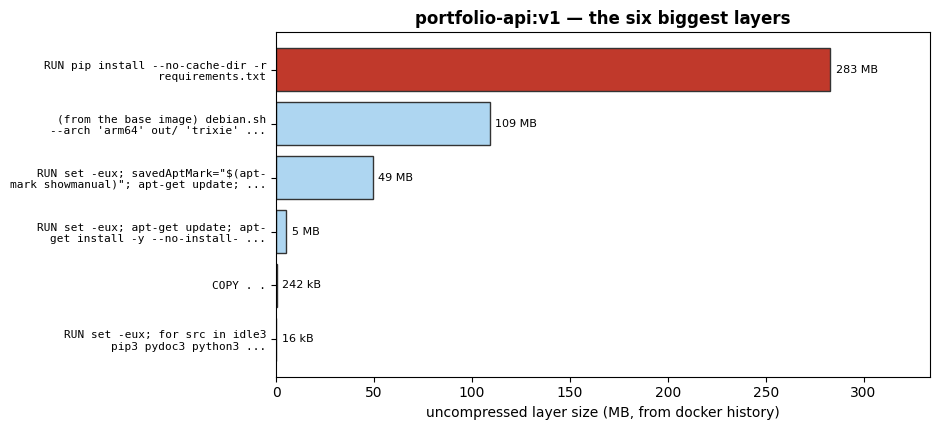

Biggest layer : RUN pip install --no-cache-dir -r requirements.txt
                283 MB = 63% of the 447 MB shown
Your code     : COPY . . is 242 kB — 1,169x smaller than the pip layer
Note: docker history reports UNCOMPRESSED layer sizes, so these bars sum to
      more than the compressed content size `docker images` printed above.


In [13]:
# WHAT: chart the real per-layer sizes of the image we just built, read from
#       `docker history portfolio-api:v1`.
# WHY: "put requirements before the code so pip is cached" and "prefer slim" are
#      claims about SIZE. This cell is the measurement behind them, not the claim.
import re
import subprocess
import textwrap

import matplotlib.pyplot as plt

# docker prints decimal units (1 kB = 1000 B), so convert with powers of 1000.
UNITS = {"B": 1, "kB": 1e3, "KB": 1e3, "MB": 1e6, "GB": 1e9}


def parse_size(text: str) -> float:
    """'283MB' -> 283000000.0 ; anything unparseable -> 0."""
    m = re.match(r"^([\d.]+)\s*([kKMG]?B)$", text.strip())
    return float(m.group(1)) * UNITS.get(m.group(2), 1) if m else 0.0


# Dockerfile instructions, so a layer that already names one is not relabelled.
KEYWORDS = {"RUN", "COPY", "ADD", "CMD", "ENV", "EXPOSE", "WORKDIR",
            "ENTRYPOINT", "LABEL", "VOLUME", "USER", "ARG"}


def short_step(created_by: str) -> str:
    """Turn a long CreatedBy string into a readable Dockerfile-step label.

    Wraps onto two lines rather than cutting mid-word: a tick label ending in
    "requiremen..." tells you nothing about which layer the bar is.
    """
    s = created_by.replace("#(nop) ", "").replace("/bin/sh -c ", "")
    s = " ".join(s.replace("# buildkit", "").strip().lstrip("# ").split())
    if s.split(" ", 1)[0] not in KEYWORDS:
        s = "(from the base image) " + s   # inherited from python:3.10-slim
    lines = textwrap.wrap(s, width=34, break_long_words=True)[:2]
    if len(lines) == 2 and len(" ".join(lines)) < len(s):
        lines[1] += " ..."                 # genuinely longer than two lines
    return "\n".join(lines)


def fmt_mb(v: float) -> str:
    """Label small layers in kB so they are not all printed as '0 MB'."""
    return f"{v * 1000:,.0f} kB" if v < 1 else f"{v:,.0f} MB"


# Ask the daemon for the layer table; an empty list means Docker could not answer.
layers = []
try:
    r = subprocess.run(
        ["docker", "history", "portfolio-api:v1", "--no-trunc",
         "--format", "{{.Size}}\t{{.CreatedBy}}"],
        capture_output=True, text=True, timeout=60,
    )
    if r.returncode == 0:
        for line in r.stdout.strip().splitlines():
            size_txt, _, created = line.partition("\t")
            nbytes = parse_size(size_txt)
            if nbytes > 0:                      # skip the many 0 B metadata layers
                layers.append((nbytes, short_step(created)))
except (FileNotFoundError, subprocess.TimeoutExpired):
    pass

if layers:
    layers.sort()
    layers = layers[-6:]                        # the six biggest layers, small to large
    sizes_mb = [n / 1e6 for n, _ in layers]
    labels = [lab for _, lab in layers]
    # Highlight the dependency-install layer: it is the one the cache ordering protects.
    colors = ["#C0392B" if "pip install" in lab else "#AED6F1" for lab in labels]

    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    ax.barh(range(len(labels)), sizes_mb, color=colors, edgecolor="#333")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8, family="monospace")
    ax.set_xlabel("uncompressed layer size (MB, from docker history)")
    ax.set_title("portfolio-api:v1 — the six biggest layers", fontweight="bold")
    for i, v in enumerate(sizes_mb):
        ax.text(v + max(sizes_mb) * 0.01, i, fmt_mb(v), va="center", fontsize=8)
    ax.set_xlim(0, max(sizes_mb) * 1.18)
    plt.tight_layout()
    plt.show()

    biggest_mb, biggest_lab = sizes_mb[-1], labels[-1]
    shown_total = sum(sizes_mb)
    print(f"Biggest layer : {biggest_lab.replace(chr(10), ' ')}")
    print(f"                {fmt_mb(biggest_mb)} = {100 * biggest_mb / shown_total:.0f}% "
          f"of the {shown_total:,.0f} MB shown")
    # The layer your code edits rebuild, for scale against the one they do not.
    code_layers = [v for v, lab in zip(sizes_mb, labels) if lab.startswith("COPY . .")]
    if code_layers:
        print(f"Your code     : COPY . . is {fmt_mb(code_layers[0])} — "
              f"{biggest_mb / code_layers[0]:,.0f}x smaller than the pip layer")
    print("Note: docker history reports UNCOMPRESSED layer sizes, so these bars sum to")
    print("      more than the compressed content size `docker images` printed above.")
else:
    print("[Docker not available] There is no local image to inspect, so no chart was")
    print("drawn. The chart stored in this notebook was measured on the machine that")
    print("published it; re-run this cell with the Docker daemon running to get yours.")


**Read the chart.** One bar dwarfs the rest: the `RUN pip install ...` layer holds every
dependency in `requirements.txt` and is more than half the image on its own. Now find
`COPY . .` in the list — it is charted like the others, and it has no visible width at
all. That one is *your entire application*: `main.py`, the model artifact, the card. The printed line
under the chart gives the ratio.

That pair of bars is the whole argument for the Dockerfile's ordering. Edit `main.py` and
Docker rebuilds only the invisible bar; edit `requirements.txt` and it pays for the red one
again. The other large bars come from `python:3.10-slim` itself — the Debian
userland and the CPython build — and they are the floor you cannot get under without
changing the base image, which is exactly why the full `python:3.10` image is the wrong
place to start.

`docker history` reports *uncompressed* layer sizes, so these bars add up to more than the
compressed content size `docker images` printed above; the two numbers measure different
things and both are real.

*(No Docker daemon on your machine? The cell says so and draws nothing — the chart above is
then the one measured when this notebook was published.)*

### The ordering claim, made visible

Section 4 claimed that copying `requirements.txt` before the code is what keeps `pip
install` out of every rebuild. The bar chart showed *how big* that layer is; it did not
show *when* Docker has to pay for it. That is a claim about a sequence of builds, so the
cell below draws the sequence.

It parses the real `app/Dockerfile` you wrote above, then applies Docker's cache rule —
**the cache holds until the first instruction whose inputs changed, and every instruction
after that one is rebuilt** — to one everyday event: *you fix a line in `main.py` and
rebuild*. The same event is then applied to the ordering most people write first, with
`COPY . .` above `pip install`. Layer sizes are the measured ones from `docker history`.
This is the documented cache rule applied to your file, not a stopwatch on two builds.

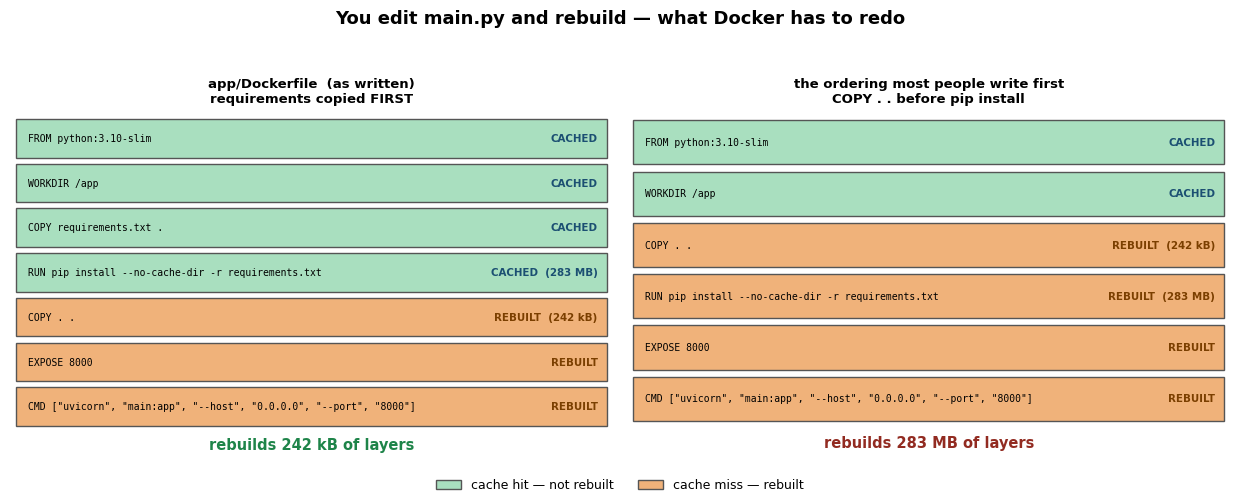

Same one-line edit to main.py: 0.2 MB rebuilt with the ordering you wrote, 283.2 MB with the naive one — 1,170x more work, every single build.


In [14]:
# WHAT: apply Docker's layer-cache rule to the real app/Dockerfile, for the event
#       "you edit main.py and rebuild" — against the naive ordering, side by side.
# WHY: the bar chart above measured how big the pip layer is. This shows how OFTEN
#      you pay for it, which is the actual argument for the Dockerfile's ordering.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Read the instructions back out of the file we wrote — the picture cannot drift
# from the Dockerfile, because it IS the Dockerfile.
with open("app/Dockerfile") as fh:
    as_written = [ln.strip() for ln in fh
                  if ln.strip() and not ln.lstrip().startswith("#")]

# The ordering almost everyone writes first: copy everything, then install.
naive = ["FROM python:3.10-slim", "WORKDIR /app", "COPY . .",
         "RUN pip install --no-cache-dir -r requirements.txt",
         'EXPOSE 8000', 'CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]']

# Measured MB per instruction, taken from the `layers` list the chart above built
# from `docker history`. Anything we cannot match is drawn without a number.
measured = {}
for nbytes, label in layers:
    flat = label.replace("\n", " ")
    if "pip install" in flat:
        measured["pip"] = nbytes / 1e6
    elif flat.startswith("COPY . ."):
        measured["copy_all"] = nbytes / 1e6


def cost(instr):
    """Measured size of this instruction's layer, or None if we have no number."""
    if instr.startswith("RUN pip install"):
        return measured.get("pip")
    if instr.startswith("COPY . ."):
        return measured.get("copy_all")
    return 0.0 if instr.startswith(("FROM", "WORKDIR", "EXPOSE", "CMD")) else None


def rebuild_from(instrs, changed_file="main.py"):
    """Index of the first instruction invalidated by editing changed_file.

    COPY . . copies main.py, so it is the first miss; COPY requirements.txt is
    not, because requirements.txt did not change.
    """
    for i, ins in enumerate(instrs):
        if ins.startswith("COPY") and not ins.startswith("COPY requirements.txt"):
            return i
    return len(instrs)


def fmt(mb):
    """0.242 MB printed as '0 MB' reads as nothing at all — say kB instead."""
    return f"{mb * 1000:,.0f} kB" if mb < 1 else f"{mb:,.0f} MB"


def short(ins):
    # Wide enough for every line in this Dockerfile, including the CMD.
    return (ins[:66] + "…") if len(ins) > 67 else ins


fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
CACHED, REBUILT = "#A9DFBF", "#F0B27A"
totals = []

for ax, (title, instrs) in zip(axes, [
        ("app/Dockerfile  (as written)\nrequirements copied FIRST", as_written),
        ("the ordering most people write first\nCOPY . . before pip install", naive)]):
    first = rebuild_from(instrs)
    n = len(instrs)
    rebuilt_mb = sum(c for c in (cost(i) for i in instrs[first:]) if c)
    totals.append(rebuilt_mb)
    for k, ins in enumerate(instrs):
        y = n - 1 - k
        hit = k < first
        ax.add_patch(mpatches.Rectangle((0, y), 1, 0.86,
                                        facecolor=CACHED if hit else REBUILT,
                                        edgecolor="#555", linewidth=1.0))
        ax.text(0.02, y + 0.43, short(ins), va="center", ha="left",
                fontsize=7.0, family="monospace")
        mb = cost(ins)
        tag = "CACHED" if hit else "REBUILT"
        if mb:
            tag += f"  ({fmt(mb)})"
        ax.text(0.985, y + 0.43, tag, va="center", ha="right", fontsize=7.4,
                fontweight="bold", color="#1B4F72" if hit else "#7B3F00")
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.75, n + 0.05)
    ax.axis("off")
    ax.set_title(title, fontsize=9.5, fontweight="bold")
    ax.text(0.5, -0.42, f"rebuilds {fmt(rebuilt_mb)} of layers",
            ha="center", va="center", fontsize=10.5, fontweight="bold",
            color="#922B21" if rebuilt_mb > 50 else "#1E8449")

fig.suptitle("You edit main.py and rebuild — what Docker has to redo",
             fontsize=13, fontweight="bold")
fig.legend(handles=[mpatches.Patch(facecolor=CACHED, edgecolor="#555", label="cache hit — not rebuilt"),
                    mpatches.Patch(facecolor=REBUILT, edgecolor="#555", label="cache miss — rebuilt")],
           loc="lower center", ncol=2, frameon=False, fontsize=9)
plt.tight_layout(rect=(0, 0.05, 1, 0.94))
plt.show()

if all(totals):
    print(f"Same one-line edit to main.py: {totals[0]:,.1f} MB rebuilt with the ordering "
          f"you wrote, {totals[1]:,.1f} MB with the naive one "
          f"— {totals[1] / max(totals[0], 1e-9):,.0f}x more work, every single build.")
else:
    print("Docker could not be queried for layer sizes, so the boxes are drawn without")
    print("MB figures. The cache hit/miss pattern is the rule and does not depend on them.")


**Read the two stacks.** Both panels describe exactly the same event — one line changed
in `main.py` — and both contain exactly the same instructions. Only the order differs, and
the order decides where the green stops.

*Left, your Dockerfile.* `FROM`, `WORKDIR`, `COPY requirements.txt` and the big
`RUN pip install` are all green: `requirements.txt` did not change, so Docker reuses those
layers untouched. The orange starts at `COPY . .`, which is the first instruction that can
see your edit. The number under the stack is what actually gets rebuilt, and it is measured in
*kilobytes*.

*Right, the ordering people reach for first.* `COPY . .` has moved above `pip install`.
Docker's rule is unchanged, but now the first cache miss happens one line earlier, and
**everything below it goes orange — including the `pip install` layer**, the same red bar
that dominated the chart above. The printed line gives the ratio between the two numbers.

Nothing about the image differs: both Dockerfiles produce the same bytes. What differs is
what you pay on every rebuild for the rest of the project's life, and the only thing that
bought it was writing two `COPY` lines in the right order.

---
## Section 6 — Running, Inspecting, and Stopping Containers

Once you have an image, you start containers from it. You can run many containers from the same image simultaneously.


In [15]:
# Start a container from the image.
# docker run flags:
#   -d           : detached mode (runs in background)
#   -p 8000:8000 : map host port 8000 to container port 8000
#   --name       : give the container a friendly name
run_docker(
    ["docker", "run", "-d", "-p", "8000:8000", "--name", "portfolio-api", "portfolio-api:v1"],
    expected="9f3a2b1c0d4e5f6a7b8c9d0e1f2a3b4c5d6e7f8a9b0c1d2e3f4a5b6c7d8e9f0a  (the new container's ID)",
)


Command: docker run -d -p 8000:8000 --name portfolio-api portfolio-api:v1


f7ffb5ed1e471ef31c87d4aa1eebf3d74bcc10238b9da6bea3811d34b5d90dea


True

In [16]:
# Inspect running containers — each row is one live container
run_docker(
    ["docker", "ps"],
    expected=(
        "CONTAINER ID  IMAGE       COMMAND       CREATED       STATUS       PORTS                  NAMES\n"
        "9f3a2b1c0d4e  portfolio-api:v1 'uvicorn ...' 5 seconds ago Up 4 seconds 0.0.0.0:8000->8000/tcp portfolio-api"
    ),
)


Command: docker ps


CONTAINER ID   IMAGE              COMMAND                  CREATED                  STATUS                  PORTS                                         NAMES
f7ffb5ed1e47   portfolio-api:v1   "uvicorn main:app --…"   Less than a second ago   Up Less than a second   0.0.0.0:8000->8000/tcp, [::]:8000->8000/tcp   portfolio-api


True

In [17]:
# View logs from the running container — the app's stdout/stderr stream
# `docker logs` reads the app's stdout — first place to look when a container misbehaves.
run_docker(
    ["docker", "logs", "portfolio-api"],
    expected=(
        "INFO:     Started server process [1]\n"
        "INFO:     Waiting for application startup.\n"
        "INFO:     Application startup complete.\n"
        "INFO:     Uvicorn running on http://0.0.0.0:8000"
    ),
)

Command: docker logs portfolio-api
(command succeeded with no output)


True

In [18]:
# Stop, then remove the container. Both commands echo the container name on
# success — the helper reports honestly if they could not run.
run_docker(["docker", "stop", "portfolio-api"], expected="portfolio-api  (the stopped container's name)")
run_docker(["docker", "rm", "portfolio-api"], expected="portfolio-api  (the removed container's name)")


Command: docker stop portfolio-api


portfolio-api
Command: docker rm portfolio-api
portfolio-api


True

---
## Section 7 — Multi-Stage Builds (Optimization)

A multi-stage build uses one image to compile/build and a separate, smaller image for the final artifact. For Python ML services, this is useful when you need to compile C extensions (e.g., `numpy` from source) but want a lean runtime image.


In [19]:
%%writefile app/Dockerfile.multistage
# WHAT: write a multi-stage Dockerfile: build with the full image, run on slim.
# WHY: compilers and build tools are needed to INSTALL packages but not to RUN
# them — copying only the installed packages into slim shrinks the image.
# ── Stage 1: builder ────────────────────────────────────────────────────────
# Uses the full image so we have compilers for C extensions
FROM python:3.10 AS builder

WORKDIR /build

# Install dependencies into a local prefix (not system site-packages)
COPY requirements.txt .
RUN pip install --no-cache-dir --prefix=/install -r requirements.txt

# ── Stage 2: runtime ────────────────────────────────────────────────────────
# slim has no compilers — much smaller
FROM python:3.10-slim

WORKDIR /app

# Copy only the installed packages from the builder stage
COPY --from=builder /install /usr/local

# Copy application code and model
COPY . .

EXPOSE 8000
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]

Overwriting app/Dockerfile.multistage


In [20]:
# Build the multi-stage image and compare its size with the single-stage one
# Same app, two Dockerfiles: the size difference is pure build-stage baggage.
run_docker(
    ["docker", "build", "-f", "app/Dockerfile.multistage", "-t", "portfolio-api:v1-slim", "app/"],
    expected=(
        "Successfully built b2c3d4e5f6a7\n"
        "Successfully tagged portfolio-api:v1-slim\n"
        "\n"
        "docker images portfolio-api would then show:\n"
        "portfolio-api  v1        a1b2c3  ...  215MB   <- single stage\n"
        "portfolio-api  v1-slim   b2c3d4  ...  148MB   <- multi-stage"
    ),
    timeout=180,
)

Command: docker build -f app/Dockerfile.multistage -t portfolio-api:v1-slim app/


(command succeeded with no output)


True

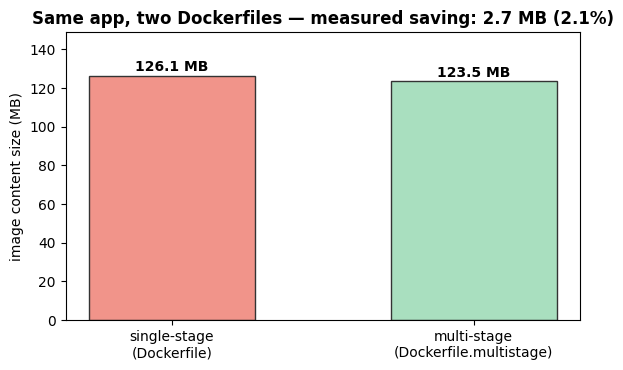

single-stage : 126.1 MB
multi-stage  : 123.5 MB
saving       : 2.7 MB  (2.1%)


In [21]:
# WHAT: compare the MEASURED sizes of the two images we just built.
# WHY: multi-stage adds real complexity to the Dockerfile. It earns that complexity
#      only if the number moves — so read the number instead of trusting the claim.
import subprocess

import matplotlib.pyplot as plt


def image_bytes(tag: str):
    """Image size in bytes as the daemon reports it; None if Docker cannot answer."""
    try:
        r = subprocess.run(
            ["docker", "image", "inspect", tag, "--format", "{{.Size}}"],
            capture_output=True, text=True, timeout=30,
        )
        return int(r.stdout.strip()) if r.returncode == 0 else None
    except (FileNotFoundError, ValueError, subprocess.TimeoutExpired):
        return None


tags = ["portfolio-api:v1", "portfolio-api:v1-slim"]
names = ["single-stage\n(Dockerfile)", "multi-stage\n(Dockerfile.multistage)"]
sizes = [image_bytes(t) for t in tags]

if all(s is not None for s in sizes):
    mb = [s / 1e6 for s in sizes]
    saved = mb[0] - mb[1]

    fig, ax = plt.subplots(figsize=(6, 3.8))
    bars = ax.bar(names, mb, color=["#F1948A", "#A9DFBF"], edgecolor="#333", width=0.55)
    for bar, v in zip(bars, mb):
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(mb) * 0.02,
                f"{v:,.1f} MB", ha="center", fontweight="bold")
    ax.set_ylabel("image content size (MB)")
    ax.set_ylim(0, max(mb) * 1.18)
    ax.set_title(f"Same app, two Dockerfiles — measured saving: "
                 f"{saved:,.1f} MB ({100 * saved / mb[0]:.1f}%)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"single-stage : {mb[0]:,.1f} MB")
    print(f"multi-stage  : {mb[1]:,.1f} MB")
    print(f"saving       : {saved:,.1f} MB  ({100 * saved / mb[0]:.1f}%)")
else:
    print("[Docker not available] One or both images are missing, so no chart was drawn.")
    print("The chart stored in this notebook was measured on the machine that published")
    print("it; re-run the two build cells with the Docker daemon running to get yours.")


**Read the chart.** The two bars are almost the same height. Multi-stage removes the
*build-time* baggage — compilers and headers used to install packages but never used to
run them — and this app installs wheels that need no compiler, so there is almost nothing
to remove. The technique is not wrong; it is simply being applied where its win does not
exist. Hold that picture next to a PyTorch + CUDA image, where the builder stage really
does carry gigabytes, and the same two bars would look nothing like this.

*(No Docker daemon on your machine? The cell says so and draws nothing.)*

## 💬 Discuss

Here is the comparison this notebook actually produced: the single-stage image reported **126.1 MB of content** and the multi-stage image **123.5 MB** — a saving of 2.7 MB, or 2.1%, which is the pair of nearly equal bars in the chart above. That is a far smaller win than the "215 MB → 148 MB" figure the fallback text quotes as typical.

1. Explain the small saving from the Dockerfiles. What is a multi-stage build actually removing, and why is there so little of it here? (Look at what is in `requirements.txt` and ask which of those packages needs a compiler to install.)
2. Given that measurement, would you keep the multi-stage Dockerfile in this project? Now change one fact — the model is PyTorch with a CUDA runtime — and answer again. What made the difference?
3. `COPY . .` copies the build context, which includes `model/model.joblib`. The image therefore contains the model. Argue for the alternative: an image with no model, downloading the artifact from a registry at startup. Which one would you rather roll back, and which would you rather audit?

---
## Summary

Docker gives you three concrete benefits for ML deployment:

1. **Reproducibility** — the exact same Python version, package versions, and OS libraries run in development, CI, and production.
2. **Isolation** — each container has its own filesystem and network, so models don't interfere with each other.
3. **Portability** — an image built on a MacBook runs unchanged on an AWS EC2 instance or a Kubernetes cluster.

The workflow is always the same: **stage the artifact** → write app files → write Dockerfile → `docker build` → `docker run`.

Notice what changed about the model between Unit 1 and here. The artifact never changed — the same file you exported from AIAT 114 or AIAT 122 has now been served three ways. What changed is *where the app looks for it*: your home directory in Units 1–2, a baked-in `model/` directory here. A container that reads its model from the host is not portable, and portability was the whole point.

**Next:** Notebook 02 covers Kubernetes — how to run many copies of this container, auto-scale them, and recover from crashes automatically.


---
## Self-Check Questions

Answer without scrolling, then verify by re-reading the relevant section.

1. **What is the difference between a Docker image and a container?**
   *(Hint: think about the cake analogy in Section 2.)*

2. **Why use `python:3.10-slim` instead of `python:3.10` as the base image?**
   *(Hint: Section 4 explains the size difference.)*

3. **What would happen if you copied all files first and then ran `pip install`, instead of copying `requirements.txt` first?**
   *(Hint: think about Docker layer caching.)*

4. **Why does `app/main.py` read `model/`, while the Unit 1 and Unit 2 apps read `~/ai-diploma-portfolio/`?**
   *(Hint: what exists inside a running container, and what does not?)*

5. **The staging step copies your artifact into the build context. What would break if you instead mounted your home directory into the container at run time?**


## ⚠️ Where this breaks

- **A Dockerfile is reproducible only as far as it is pinned.** `FROM python:3.10-slim` is a moving tag; `pip install -r requirements.txt` resolves at build time. Rebuild in six months and you may get different patch versions, a different base image and — as the torchtriton incident shows — potentially a different *package* under the same name. For anything that must be reproducible, pin the base image by digest (`python:3.10-slim@sha256:...`), pin every dependency exactly, and prefer a lockfile.
- **Multi-stage builds save what they save.** Measured here: about 2 MB. The technique pays when your dependencies compile C extensions from source or need build toolchains; it pays nothing when they are pure-Python or ship manylinux wheels. Do not carry the extra complexity on faith — build both and read the numbers, as this notebook did.
- **The base image is your attack surface, and it ages.** `python:3.10-slim` contains an operating system with its own CVEs. An image built today and deployed for a year is a year of unpatched libraries. Rebuilding on a schedule is not busywork; it is patching. Scanning images (`docker scout`, `trivy`) belongs in CI (notebook 04).
- **The assumption that must hold:** the container gets everything from inside itself. Bake the model in and the image is portable but the model is frozen at build time — every retrain means a rebuild and a redeploy. Mount the model instead and updates get easy, portability is gone, and you have reintroduced "works on my machine" at the volume-mount level. Choose deliberately; both are defensible and the failure comes from choosing by accident.
- **Docker does not fix hardware.** An image built on Apple silicon does not run on an x86 node without a multi-architecture build, and a container running on a laptop with 16 GB does not tell you what happens under a 512 MB Kubernetes memory limit — the process is simply killed.
- **The cheaper alternative.** For a one-off analysis or a script a single person runs, a pinned virtual environment and a `requirements.txt` is honest, sufficient and far quicker. Containers earn their cost when the artifact must run somewhere you do not control.

## 📚 References

1. Merkel, D. (2014). *Docker: Lightweight Linux Containers for Consistent Development and Deployment*. Linux Journal. <https://www.linuxjournal.com/content/docker-lightweight-linux-containers-consistent-development-and-deployment>
2. Boettiger, C. (2015). *An Introduction to Docker for Reproducible Research*. ACM SIGOPS Operating Systems Review 49(1). <https://arxiv.org/abs/1410.0846>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Zhao, J., Wang, S., Zhao, Y., et al. (2024). *Models Are Codes: Towards Measuring Malicious Code Poisoning Attacks on Pre-trained Model Hubs*. arXiv:2409.09368. <https://arxiv.org/abs/2409.09368>
5. Stalnaker, T., Wintersgill, N., Chaparro, O., et al. (2025). *An Empirical Analysis of Machine Learning Model and Dataset Documentation, Supply Chain, and Licensing Challenges on Hugging Face*. arXiv:2502.04484. <https://arxiv.org/abs/2502.04484>